In [1]:
# 마스터가 워커노드에 데이터 전송
# 워커가 실시간 FFT분석 결과 반환

In [2]:
# master : 가상의 신호를 생성하여 worker에게 전송하고, worker로부터 FFT 결과를 받아 시간을 확인

In [8]:
import socket # TCP 통신을 위한 소켓 라이브러리
import numpy as np
import time 
import matplotlib.pyplot as plt

In [9]:
HOST = "localhost" #마스터 서버 주소
PORT = 9995  # 통신 포트

In [10]:
# 실시간 하드웨어로부터 시그널 데이터 받으면 워커노드에게 분산시켜서 일 시키고, 노드마다 분산해서 작업하고 마스터에게 피드백

In [11]:
# 신호 생성 
signal_length = 30000 # 데이터 길이 (샘플 개수)

# 정규분포 기반 랜덤 신호 생성
signal = np.random.randn(signal_length).astype(np.float32) # 데이터 용량 줄이기 위해서 32가 4BYTE니까 용량 줄일 수 있는 효과 있음.

In [13]:
# 한글 폰트 설정
from matplotlib import font_manager, rc
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font',family=font_name)

Master : Worker 접속 대기 중....
master : worker 접속됨 - 주소 : ('127.0.0.1', 49764)
master : 신호전송 시작
master : 신호 전송 완료, 결과 대기 중......
master : FFT 결과 수신 완료 (길이 : 30000)
[왕복 처리 시간] 0.002999 초


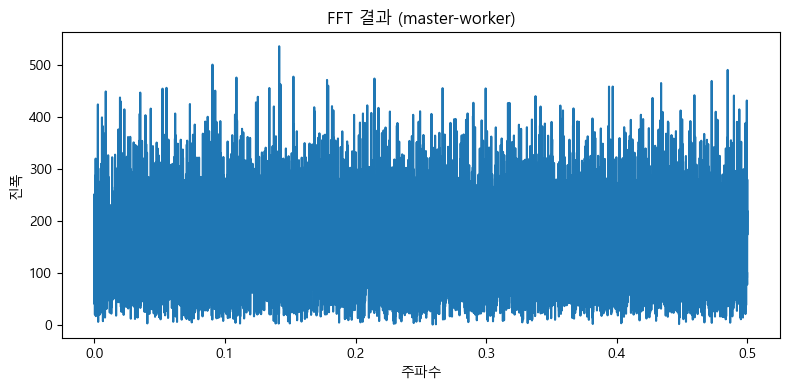

In [14]:
# TCP 서버 시작
with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s: # TCP 세션을 만들고, s 로 요약한 것.
    s.bind((HOST,PORT)) # 서버 주소와 포트 연결
    s.listen() # 클라이언트 접속 대기

    print("Master : Worker 접속 대기 중....")

    conn, addr = s.accept() # worker 점속시 까지 대기

    with conn:
        print(f"master : worker 접속됨 - 주소 : {addr}")
        start_time = time.time() # 처리 시간 측정 시작
        print("master : 신호전송 시작")

        conn.sendall(signal.tobytes()) # numpy type --> bytes 로 변환 후 전송
        print("master : 신호 전송 완료, 결과 대기 중......")

        # 데이터 수신
        expected_bytes = signal_length * 4 #flaot 32 -> 4bytes
        received = b"" # 수신 데이터 누적 

        # tcp는 데이터가 쪼개져서 들어오기 때문에 반복 수신 처리 필요
        while len(received) < expected_bytes:
            chunk = conn.recv(4096)

            if not chunk: # 데이터 없으면 연결 종료
                break
            received += chunk # 데이터 누적

        # 데이터 변환
        fft_result = np.frombuffer(received, dtype = np.float32)
        print(f"master : FFT 결과 수신 완료 (길이 : {len(fft_result)})")
    
        # 처리시간 측정 완료
        end_time = time.time()
        elapsed = end_time-start_time
    
        print(f"[왕복 처리 시간] {elapsed:.4} 초")

    # 결과 시각화
    # FFT 결과는 주파수 데이터임
    freqs = np.fft.fftfreq(signal_length, d = 1.0)
    plt.figure(figsize=(8,4))

    plt.plot(
        freqs[:signal_length //2 ],
        fft_result[:signal_length //2 ]
    )

    plt.xlabel("주파수")
    plt.ylabel("진폭")
    plt.title("FFT 결과 (master-worker)")

    plt.tight_layout()
    plt.show()
    

    